In [ ]:
%pip install -Uq "unstructured[all-docs]"

# Install image and HTML/XML parsing libraries
%pip install -Uq pillow lxml

# Install vector DB and token counting
%pip install -Uq chromadb tiktoken

# Install LangChain core and integrations
%pip install -Uq langchain langchain-community langchain-openai langchain-groq

# Install dotenv for environment variable management
%pip install -Uq python-dotenv


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 17.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 100.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 99.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.9/527.9 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.7/48.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 110.7 MB/s eta 0:00:00


In [ ]:
!apt-get install poppler-utils

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 35 not upgraded.
Need to get 186 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.10 [186 kB]
Fetched 186 kB in 1s (314 kB/s)
Selecting previously unselected package poppler-utils.
(Reading database ... 126371 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.10_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.10) ...
Setting up poppler-utils (22.02.0-2ubuntu0.10) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
from unstructured.partition.pdf import partition_pdf

output_path = "/content/"
file_path = '/content/attention.pdf'

chunks = partition_pdf(
    filename=file_path,
    infer_table_structure=True,
    strategy="hi_res",

    extract_image_block_types=["Image","Table"],   # Add 'Table' to list to extract image of tables

    extract_image_block_to_payload=True,   # if true, will extract base64 for API usage

    chunking_strategy="by_title",
    # max_characters=10000,
    # combine_text_under_n_chars=2000,
    # new_after_n_chars=6000,
)


yolox_l0.05.onnx:   0%|          | 0.00/217M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/274 [00:00<?, ?B/s]

The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

In [ ]:
set([str(type(el)) for el in chunks])

{"<class 'unstructured.documents.elements.CompositeElement'>",
 "<class 'unstructured.documents.elements.TableChunk'>"}

In [ ]:
for i in range(len(chunks)):
    elements = chunks[i].metadata.orig_elements
    chunk_images = [el for el in elements if 'Image' in str(type(el))]
    if chunk_images:
        print(chunk_images)

[<unstructured.documents.elements.Image object at 0x7944140ab6b0>, <unstructured.documents.elements.Image object at 0x7944140a9e80>]


In [ ]:
elements = chunks[-1].metadata.orig_elements
chunk_images = [el for el in elements if 'Image' in str(type(el))]
chunk_images[0].to_dict()

{'type': 'Image',
 'element_id': '5743dfa8-b7e2-4c21-8413-fa93580fdde3',
 'text': '<ped> <ped> so ————_<S0 UO|UIdO uoluldo Aw Aw ul ul Bulssiw Bulssiw ae ale aM am yeum yeum s| s| sty} # sly -— - a 3q 3q Pinoys « pinoys uoyjeoijdde ee Ss}! Ss}! inq ee popod oo ated 3q 3q JOABU JOABU IW IW rn aul aul',
 'metadata': {'detection_class_prob': 0.3270053267478943,
  'coordinates': {'points': ((np.float64(342.73736572265625),
     np.float64(1125.3592529296875)),
    (np.float64(342.73736572265625), np.float64(1639.5025634765625)),
    (np.float64(1369.6767578125), np.float64(1639.5025634765625)),
    (np.float64(1369.6767578125), np.float64(1125.3592529296875))),
   'system': 'PixelSpace',
   'layout_width': 1700,
   'layout_height': 2200},
  'last_modified': '2025-08-30T13:48:22',
  'filetype': 'PPM',
  'languages': ['eng'],
  'page_number': 15,
  'image_base64': '...',
  'image_mime_type': 'image/jpeg'}}

In [ ]:
tables = []
texts = []

for chunk in chunks:
    if "Table" in str(type(chunk)):
        tables.append(chunk)

    if "CompositeElement" in str(type((chunk))):
        texts.append(chunk)

In [ ]:
tables

In [ ]:
def get_images_base64(chunks):
    images_b64 = []
    for chunk in chunks:
        if "CompositeElement" in str(type(chunk)):
            chunk_els = chunk.metadata.orig_elements
            for el in chunk_els:
                if "Image" in str(type(el)):
                    images_b64.append(el.metadata.image_base64)
    return images_b64

images = get_images_base64(chunks)

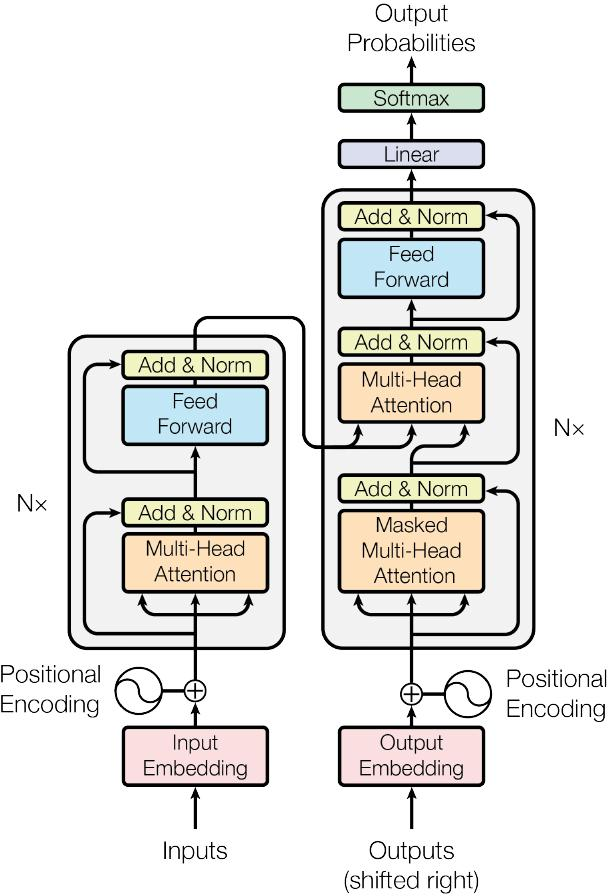

In [ ]:
import base64
from IPython.display import Image, display

def display_base64_image(base64_code):
    # Decode the base64 string to binary
    image_data = base64.b64decode(base64_code)
    # Display the image
    display(Image(data=image_data))

display_base64_image(images[0])

In [ ]:
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [ ]:
from google.colab import userdata
import os
os.environ['GROQ_API_KEY'] = userdata.get('GROQ_API_KEY')
os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')

In [ ]:
 # Prompt
prompt_text = """
You are an assistant tasked with summarizing tables and text.
Give a concise summary of the table or text.

Respond only with the summary, no additionnal comment.
Do not start your message by saying "Here is a summary" or anything like that.
Just give the summary as it is.

Table or text chunk: {element}

"""
prompt = ChatPromptTemplate.from_template(prompt_text)

# Summary chain
model = ChatGroq(temperature=0.5, model="llama-3.1-8b-instant")
summarize_chain = {"element": lambda x: x} | prompt | model | StrOutputParser()

In [ ]:
# Summarize text
text_summaries = summarize_chain.batch(texts, {"max_concurrency": 1})

# Summarize tables
tables_html = [table.metadata.text_as_html for table in tables]
table_summaries = summarize_chain.batch(tables_html, {"max_concurrency": 1})

In [ ]:
table_summaries

['The table compares various machine translation models, including ByteNet, GNMT + RL, ConvS2S, MoE, and Transformer, across different metrics such as BLEU scores, training complexity, and computational cost. The Transformer (big) model achieves the highest BLEU score of 41.8 in the EN-FR translation task.',
 'The table compares parser performance on the WSJ 23 F1 dataset, with various training methods and models achieving F1 scores ranging from 88.3 to 92.1, with semi-supervised models generally performing better.',
 "The table compares three models' performance: Transformer (92.7%), Luong et al. (93.0%), and Dyer et al. (93.3%), with varying training methods (semi-supervised, multi-task, generative)."]

In [ ]:
import time


prompt_template = """Describe the image in detail. For context,
                  the image is part of a research paper explaining the transformers
                  architecture. Be specific about graphs, such as bar plots."""


messages = [
    (
        "user",
        [
            {"type": "text", "text": prompt_template},
            {
                "type": "image_url",
                "image_url": {"url": "data:image/jpeg;base64,{image}"},
            },
        ],
    )
]

prompt = ChatPromptTemplate.from_messages(messages)

chain = prompt | ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct") | StrOutputParser()


image_summaries = chain.batch(images)

In [ ]:
image_summaries[0]

"The image presents a detailed flowchart illustrating the architecture of a transformer model, which is a type of neural network designed primarily for natural language processing tasks. The chart is divided into two main sections: the left side represents the encoder, and the right side represents the decoder.\n\n**Encoder (Left Side):**\n\n*   **Input Embedding:** The process begins with input embedding, where the input text is converted into a numerical representation that the model can understand.\n*   **Positional Encoding:** This step adds positional information to the input embeddings to preserve the sequence order.\n*   **Nx (Multi-Head Attention and Feed Forward):** The encoder consists of a stack of identical layers, each comprising two sub-layers:\n    *   **Multi-Head Attention:** This mechanism allows the model to attend to different parts of the input sequence simultaneously and weigh their importance.\n    *   **Feed Forward:** A fully connected feed-forward network appl

In [ ]:
import uuid
from langchain.vectorstores import Chroma
from langchain.storage import InMemoryStore
from langchain.schema.document import Document
from langchain.embeddings import OpenAIEmbeddings
from langchain.embeddings import HuggingFaceEmbeddings
from langchain.retrievers.multi_vector import MultiVectorRetriever

# The vectorstore to use to index the child chunks
huggingface_embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-mpnet-base-v2"
)
vectorstore = Chroma(collection_name="multi_modal_rag", embedding_function=huggingface_embeddings)

# The storage layer for the parent documents
store = InMemoryStore()
id_key = "doc_id"

# The retriever (empty to start)
retriever = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=store,
    id_key=id_key,
)

/tmp/ipython-input-9156996.py:10: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  huggingface_embeddings = HuggingFaceEmbeddings(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

/tmp/ipython-input-9156996.py:13: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-chroma package and should be used instead. To use it run `pip install -U :class:`~langchain-chroma` and import as `from :class:`~langchain_chroma import Chroma``.
  vectorstore = Chroma(collection_name="multi_modal_rag", embedding_function=huggingface_embeddings)


In [ ]:
# Add texts
doc_ids = [str(uuid.uuid4()) for _ in texts]
summary_texts = [
    Document(page_content=summary, metadata={id_key: doc_ids[i]}) for i, summary in enumerate(text_summaries)
]
retriever.vectorstore.add_documents(summary_texts)
retriever.docstore.mset(list(zip(doc_ids, texts)))

# Add tables
table_ids = [str(uuid.uuid4()) for _ in tables]
summary_tables = [
    Document(page_content=summary, metadata={id_key: table_ids[i]}) for i, summary in enumerate(table_summaries)
]
retriever.vectorstore.add_documents(summary_tables)
retriever.docstore.mset(list(zip(table_ids, tables)))

# Add image summaries
img_ids = [str(uuid.uuid4()) for _ in images]
summary_img = [
    Document(page_content=summary, metadata={id_key: img_ids[i]}) for i, summary in enumerate(image_summaries)
]
retriever.vectorstore.add_documents(summary_img)
retriever.docstore.mset(list(zip(img_ids, images)))

In [ ]:
# Retrieve
docs = retriever.invoke(
    "what is multi head attention?"
)

In [ ]:
for doc in docs:
    print(str(doc) + "\n\n" + "-" * 80)

3.2.2 Multi-Head Attention

Instead of performing a single attention function with dmodel-dimensional keys, values and queries, we found it beneficial to linearly project the queries, keys and values h times with different, learned linear projections to dk, dk and dv dimensions, respectively. On each of these projected versions of queries, keys and values we then perform the attention function in parallel, yielding dv-dimensional

--------------------------------------------------------------------------------
Multi-head attention allows the model to jointly attend to information from different representation subspaces at different positions. With a single attention head, averaging inhibits this.

MultiHead(Q,K,V ) = Concat(head1,...,headh)W O where headi = Attention(QW Q i ,KW K i ,V W V i )

Where the projections are parameter matrices W Q and W O ∈ Rhdv×dmodel. i ∈ Rdmodel×dk, W K i ∈ Rdmodel×dk, W V i ∈ Rdmodel×dv

-------------------------------------------------------------------

In [ ]:
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_groq import ChatGroq
from base64 import b64decode


def parse_docs(docs):
    """Split base64-encoded images and texts"""
    b64 = []
    text = []
    for doc in docs:
        print(doc)
        try:
            b64decode(doc)
            b64.append(doc)
        except Exception as e:
            text.append(doc)
    return {"images": b64, "texts": text}


def build_prompt(kwargs):

    docs_by_type = kwargs["context"]
    user_question = kwargs["question"]
    print(docs_by_type)
    print("DOCS")

    context_text = ""
    if len(docs_by_type["texts"]) > 0:
        for text_element in docs_by_type["texts"]:
            context_text += text_element.text

    # construct prompt with context (including images)
    prompt_template = f"""
    Answer the question based only on the following context, which can include text, tables, and the below image.
    Context: {context_text}
    Question: {user_question}
    """

    prompt_content = [{"type": "text", "text": prompt_template}]

    if len(docs_by_type["images"]) > 0:
        for image in docs_by_type["images"]:
            prompt_content.append(
                {
                    "type": "image_url",
                    "image_url": {"url": "data:image/jpeg;base64,{image}"}
                }
            )

    return ChatPromptTemplate.from_messages(
        [
            HumanMessage(content=prompt_content),
        ]
    )


chain = (
    {
        "context": retriever | RunnableLambda(parse_docs),
        "question": RunnablePassthrough(),
    }
    | RunnableLambda(build_prompt)
    | ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")
    | StrOutputParser()
)

chain_with_sources = {
    "context": retriever | RunnableLambda(parse_docs),
    "question": RunnablePassthrough(),
} | RunnablePassthrough().assign(
    response=(
        RunnableLambda(build_prompt)
        | ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")
        | StrOutputParser()
    )
)

In [ ]:
response = chain.invoke(
    "What is the multi head attention mechanism?"
)

print(response)

According to the context, the multi-head attention mechanism is defined as:

**MultiHead(Q,K,V ) = Concat(head1,...,headh)W O**

where 

**headi = Attention(QW Q i ,KW K i ,V W V i )**

In essence, multi-head attention allows the model to jointly attend to information from different representation subspaces at different positions. It works by:

1. Linearly projecting the queries, keys, and values h times with different learned linear projections to dk, dk, and dv dimensions, respectively.
2. Performing the attention function in parallel on each of these projected versions of queries, keys, and values, yielding dv-dimensional outputs.
3. Concatenating the outputs from each attention head.
4. Applying a linear transformation using the parameter matrix WO.

In this specific implementation, h = 8 parallel attention layers, or heads, are employed, with dk = dv = dmodel/h = 64.


In [ ]:
response = chain_with_sources.invoke(
    "What is multi head attention?"
)

print("Response:", response['response'])

print("\n\nContext:")
for text in response['context']['texts']:
    print(text.text)
    print("Page number: ", text.metadata.page_number)
    print("\n" + "-"*50 + "\n")
for image in response['context']['images']:
    display_base64_image(image)

3.2.2 Multi-Head Attention

Instead of performing a single attention function with dmodel-dimensional keys, values and queries, we found it beneficial to linearly project the queries, keys and values h times with different, learned linear projections to dk, dk and dv dimensions, respectively. On each of these projected versions of queries, keys and values we then perform the attention function in parallel, yielding dv-dimensional
Multi-head attention allows the model to jointly attend to information from different representation subspaces at different positions. With a single attention head, averaging inhibits this.

MultiHead(Q,K,V ) = Concat(head1,...,headh)W O where headi = Attention(QW Q i ,KW K i ,V W V i )

Where the projections are parameter matrices W Q and W O ∈ Rhdv×dmodel. i ∈ Rdmodel×dk, W K i ∈ Rdmodel×dk, W V i ∈ Rdmodel×dv
6

1024

4096

16

0.3

300K 4.33

26.4

development set, newstest2013. We used beam search as described in the previous section, but no checkpoint av

In [ ]:
response

{'context': {'images': [],
  'texts': [<unstructured.documents.elements.CompositeElement at 0x794414191790>,
   <unstructured.documents.elements.CompositeElement at 0x7944141d9bb0>]},
 'question': 'What is transformer model?',
 'response': 'The Transformer model is a model architecture that eschews recurrence and instead relies entirely on an attention mechanism to draw global dependencies between input and output. \n\nIn other words, it is a model that allows for significantly more parallelization and can reach a new state of the art in translation quality, as described in the provided context. The architecture of the Transformer model is illustrated in Figure 1, which shows the different components of the model, including:\n\n* Input and output embeddings\n* Positional encoding\n* Masked multi-head attention\n* Feed forward network\n* Add and norm layers\n\nThe Transformer model was proposed by replacing RNNs with self-attention, and its design and implementation involved the contrib